In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
working_dir = os.getcwd() 

In [3]:
new_data_dir = f'{working_dir}/new_data'
new_scope_filename = f'hte_rates_drug_scope'
new_scope = pd.read_csv(f'{new_data_dir}/{new_scope_filename}.csv')
new_scope['is_biased'] = new_scope['Slow_unreliable'] == True
new_scope['bias'] = np.where(new_scope['is_biased'], new_scope['Controls']*1.5 - new_scope['HTE_rate'], 0)
print(new_scope.shape)

(11, 15)


In [4]:
from src.data_processing import load_and_process_features
from src.model_building import create_combined_dataset

acid_feature_data, amine_feature_data = load_and_process_features(new_scope)

key_features = ['amine_class_1_mixture', 
                'acyl_class_aromatic', 
                'acyl_Charges_secondary_1', 
                'amine_Charges_secondary_1', 
                'acyl_pka_aHs_x_has_acidic_H', 
                'amine_pka_basic', 
                'acyl_BV_secondary_2', 
                'amine_BV_secondary_avg']

combined_df, _ = create_combined_dataset(acid_feature_data, amine_feature_data, new_scope, key_features, save_df=False)
print(combined_df.shape)
combined_df.head()

Found 5 hydrogen-dependent features: ['num_Hs', 'BV_Hs_avg', 'Charges_Hs_avg', 'fukui_E_Hs_avg', 'fukui_N_Hs_avg']
Found 2 pKa-dependent features: ['pka_aHs', 'pka_lowest']
Found 26 heteroatom-dependent features: ['BV_main_1', 'Charges_main_atom', 'fukui_E_main_atom', 'fukui_N_main_atom', 'L_main_atom_1', 'L_main_atom_2', 'B1_main_atom_1', 'B1_main_atom_2', 'B5_main_atom_1', 'B5_main_atom_2', 'Charges_secondary_1', 'Charges_secondary_2', 'fukui_N_secondary_1', 'fukui_N_secondary_2', 'Charges_secondary_avg', 'fukui_N_secondary_avg', 'FCS_1', 'FREQS_1', 'FCS_2', 'FREQS_2', 'FCS_avg', 'FREQS_avg', 'BV_Hs_avg', 'Charges_Hs_avg', 'fukui_E_Hs_avg', 'fukui_N_Hs_avg']

Processing num_Hs conditional features...
  18/46 molecules meet condition num_Hs
    num_Hs: 0 -> 0 NA values
    BV_Hs_avg: 28 -> 0 NA values
    Charges_Hs_avg: 28 -> 0 NA values
    fukui_E_Hs_avg: 28 -> 0 NA values
    fukui_N_Hs_avg: 28 -> 0 NA values

Processing pKa_features conditional features...
  18/46 molecules meet 

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,is_biased,bias,acyl_class_aromatic,acyl_Charges_secondary_1,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg
0,rxn_07_49,7,54,16.838853,0.0,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,ClC(=O)c1sccc1,...,False,0.0,False,-0.180260,0.0,114.114473,False,-0.026113,9.42,65.397280
1,rxn_22_49,22,54,1.092647,0.0,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CCCCC(CC)C(Cl)=O,...,False,0.0,False,-0.193535,14.8,115.811976,False,-0.026113,9.42,65.397280
2,rxn_07_50,7,55,16.838853,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)c1sccc1,...,False,0.0,False,-0.180260,0.0,114.114473,False,0.007275,9.31,82.199216
3,rxn_22_50,22,55,1.092647,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCC(CC)C(Cl)=O,...,False,0.0,False,-0.193535,14.8,115.811976,False,0.007275,9.31,82.199216
4,rxn_25_50,25,55,368.625181,0.0,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCCCCCCCCC(Cl)=O,...,False,0.0,False,-0.191172,14.9,85.361508,False,0.007275,9.31,82.199216


In [5]:
combined_csv = f"{new_data_dir}/combined_features_{new_scope_filename}.csv"
combined_df.to_csv(combined_csv, index=False)

# Individual predictions

In [6]:
from src.load_models import load_models_simple

# Load all models with the same suffix
predictor = load_models_simple("_each_8_1_optuna")

# Make predictions
n = -1
feature_data = combined_df[key_features].iloc[n].to_dict()
predicted_bias = predictor.predict_bias(feature_data)
predicted_class = predictor.predict_rate_class(feature_data)

print(f"\nPredictions for {combined_df.iloc[n]['reaction']}")
print(f"Predicted class: {predicted_class}")
if predicted_class == 1:
    print("This is a fast instant reaction!! (Unmeasurable)")
else:
    print("This is a measurable reaction")
    print(f"Predicted bias: {predicted_bias}")


Successfully loaded models:
  Classifier suffix: _each_8_1_optuna
  Regressor suffix: _each_8_1_optuna
  Features suffix: _each_8_1_optuna
  Features: 8

Predictions for rxn_31_55
Predicted class: 0
This is a measurable reaction
Predicted bias: 0.0


# Predictions in Batches

In [7]:
from src.load_models import load_and_predict_batch

# Process entire CSV files
results = load_and_predict_batch(
    combined_csv,
    classifier_suffix='_each_8_1_optuna',
    regressor_suffix='_each_8_1_optuna',
    features_suffix='_each_8_1_optuna',
    save_results=True
)

Loaded 11 rows from /Users/liliana/Research/CMU/Isayev/Projects/Collaborations/Bernhard_Amide-coupling/manuscript/analysis/ml_measurable_hte_rates/new_data/combined_features_hte_rates_drug_scope.csv
Successfully loaded models:
  Classifier suffix: _each_8_1_optuna
  Regressor suffix: _each_8_1_optuna
  Features suffix: _each_8_1_optuna
  Features: 8
Making predictions...
Predictions complete
  Average predicted bias: 23.307
  Predicted classes: {1: 7, 0: 4}
Results saved to /Users/liliana/Research/CMU/Isayev/Projects/Collaborations/Bernhard_Amide-coupling/manuscript/analysis/ml_measurable_hte_rates/new_data/combined_features_hte_rates_drug_scope_with_predictions.csv


# Visualize Results

In [13]:
preds = pd.read_csv(f"{combined_csv.split('.')[0]}_with_predictions.csv")
preds['HTE_rate_corr'] = preds['HTE_rate'] - preds['predicted_bias']
preds.tail(10)

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,acyl_Charges_secondary_1,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg,predicted_bias,predicted_class,HTE_rate_corr
1,rxn_22_49,22,54,1.092647,0.00,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,-0.026113,9.42,65.397280,0.000000,1,0.000000
2,rxn_07_50,7,55,16.838853,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)c1sccc1,...,-0.180260,0.0,114.114473,False,0.007275,9.31,82.199216,0.000000,1,0.000000
3,rxn_22_50,22,55,1.092647,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,0.007275,9.31,82.199216,0.000000,1,0.000000
4,rxn_25_50,25,55,368.625181,0.00,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,CCCCCCCCCCCC(Cl)=O,...,-0.191172,14.9,85.361508,False,0.007275,9.31,82.199216,0.000000,1,0.000000
5,rxn_07_51,7,56,16.838853,154.66,False,False,2.189378,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,ClC(=O)c1sccc1,...,-0.180260,0.0,114.114473,False,0.045874,8.40,100.446591,17.202915,0,137.457085
6,rxn_14_51,14,56,518.871701,300.69,False,True,2.478119,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,CC(Cl)=O,...,-0.189124,14.6,48.659668,False,0.045874,8.40,100.446591,219.535440,0,81.154560
7,rxn_22_51,22,56,1.092647,3.70,False,False,0.568202,C[C@@H](NCCCC1=CC(C(F)(F)F)=CC=C1)C2=CC=CC3=CC...,CCCCC(CC)C(Cl)=O,...,-0.193535,14.8,115.811976,False,0.045874,8.40,100.446591,19.637338,0,-15.937338
8,rxn_03_54,3,54,3.638350,NaN,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CC(C)(C)c1ccc(cc1)C(Cl)=O,...,-0.196040,0.0,112.496459,False,-0.026113,9.42,65.397280,0.000000,1,NaN
9,rxn_10_54,10,54,3.740117,NaN,True,False,NaN,CNCCC(OC1=CC=C(C(F)(F)F)C=C1)C2=CC=CC=C2,CC(C)(C)C(Cl)=O,...,-0.194645,0.0,116.759566,False,-0.026113,9.42,65.397280,0.000000,1,NaN
10,rxn_31_55,31,55,3.349492,NaN,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)C12CC3CC(CC(C3)C1)C2,...,-0.200922,0.0,139.407585,False,0.007275,9.31,82.199216,0.000000,0,NaN


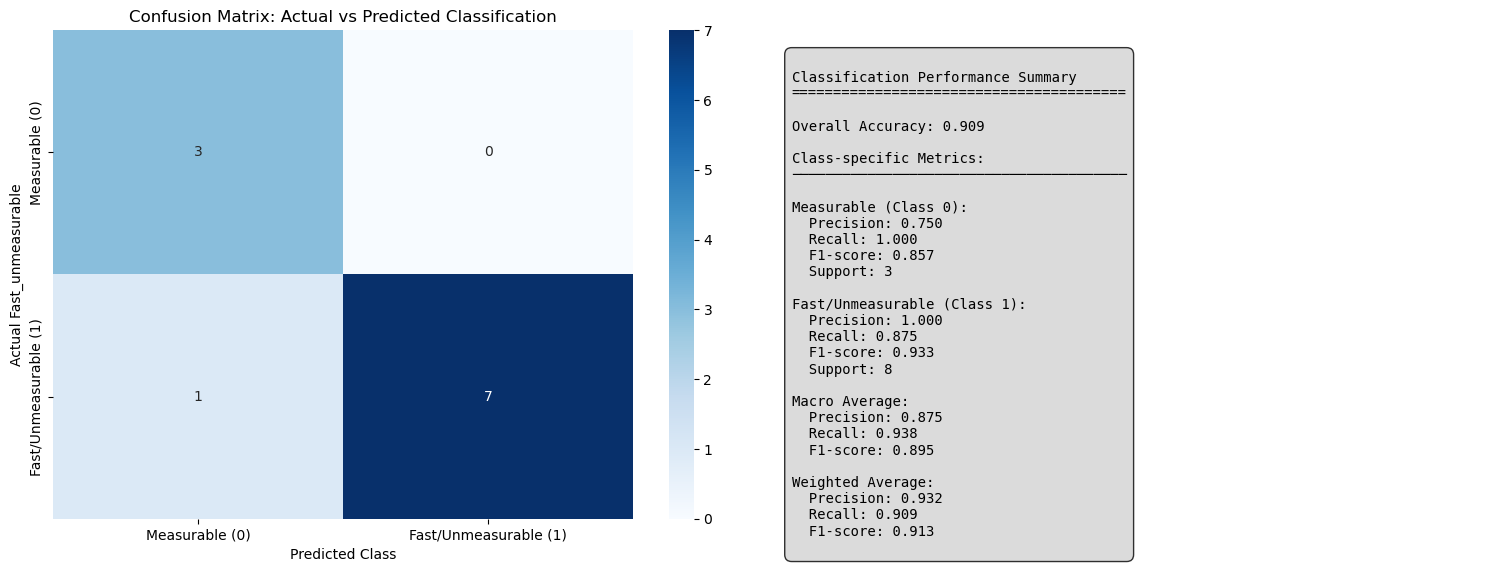


Detailed Classification Report:
                   precision    recall  f1-score   support

       Measurable       0.75      1.00      0.86         3
Fast/Unmeasurable       1.00      0.88      0.93         8

         accuracy                           0.91        11
        macro avg       0.88      0.94      0.90        11
     weighted avg       0.93      0.91      0.91        11


Misclassification Analysis:
Total misclassified: 1 out of 11 (9.1%)

False Positives (Predicted Fast/Unmeasurable but actually Measurable):
Count: 0

False Negatives (Predicted Measurable but actually Fast/Unmeasurable):
Count: 1
HTE rate range: nan - nan


In [42]:
#### from the new predictions, visualize the Fast_unmeasurable to predicted classification
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Confusion Matrix
ax1 = axes[0]
cm = confusion_matrix(preds['Fast_unmeasurable'], preds['predicted_class'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Measurable (0)', 'Fast/Unmeasurable (1)'],
            yticklabels=['Measurable (0)', 'Fast/Unmeasurable (1)'])
ax1.set_title('Confusion Matrix: Actual vs Predicted Classification')
ax1.set_xlabel('Predicted Class')
ax1.set_ylabel('Actual Fast_unmeasurable')

# 2. Overall classification metrics
ax2 = axes[1]
ax2.axis('off')

# Calculate metrics
accuracy = np.mean(preds['Fast_unmeasurable'] == preds['predicted_class'])
report = classification_report(preds['Fast_unmeasurable'], preds['predicted_class'], 
                             target_names=['Measurable', 'Fast/Unmeasurable'], 
                             output_dict=True)

# Create text summary
metrics_text = f"""
Classification Performance Summary
{'='*40}

Overall Accuracy: {accuracy:.3f}

Class-specific Metrics:
{'─'*40}

Measurable (Class 0):
  Precision: {report['Measurable']['precision']:.3f}
  Recall: {report['Measurable']['recall']:.3f}
  F1-score: {report['Measurable']['f1-score']:.3f}
  Support: {int(report['Measurable']['support'])}

Fast/Unmeasurable (Class 1):
  Precision: {report['Fast/Unmeasurable']['precision']:.3f}
  Recall: {report['Fast/Unmeasurable']['recall']:.3f}
  F1-score: {report['Fast/Unmeasurable']['f1-score']:.3f}
  Support: {int(report['Fast/Unmeasurable']['support'])}

Macro Average:
  Precision: {report['macro avg']['precision']:.3f}
  Recall: {report['macro avg']['recall']:.3f}
  F1-score: {report['macro avg']['f1-score']:.3f}

Weighted Average:
  Precision: {report['weighted avg']['precision']:.3f}
  Recall: {report['weighted avg']['recall']:.3f}
  F1-score: {report['weighted avg']['f1-score']:.3f}
"""

ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed confusion matrix
print("\nDetailed Classification Report:")
print("="*50)
print(classification_report(preds['Fast_unmeasurable'], preds['predicted_class'], 
                          target_names=['Measurable', 'Fast/Unmeasurable']))

# Additional analysis: misclassified reactions
print("\nMisclassification Analysis:")
print("="*30)
misclassified = preds[preds['Fast_unmeasurable'] != preds['predicted_class']]
print(f"Total misclassified: {len(misclassified)} out of {len(preds)} ({len(misclassified)/len(preds)*100:.1f}%)")

if len(misclassified) > 0:
    print("\nFalse Positives (Predicted Fast/Unmeasurable but actually Measurable):")
    false_positives = misclassified[misclassified['Fast_unmeasurable'] == False]
    print(f"Count: {len(false_positives)}")
    if len(false_positives) > 0:
        print(f"HTE rate range: {false_positives['HTE_rate'].min():.2f} - {false_positives['HTE_rate'].max():.2f}")
    
    print("\nFalse Negatives (Predicted Measurable but actually Fast/Unmeasurable):")
    false_negatives = misclassified[misclassified['Fast_unmeasurable'] == True]
    print(f"Count: {len(false_negatives)}")
    if len(false_negatives) > 0:
        print(f"HTE rate range: {false_negatives['HTE_rate'].min():.2f} - {false_negatives['HTE_rate'].max():.2f}")


In [44]:
misclassified['rxn_smiles'] = misclassified['amine_smiles'] + '.' + misclassified['acid_smiles']
misclassified.head()

,reaction,acyl_chlorides,amines,Controls,HTE_rate,Fast_unmeasurable,Slow_unreliable,HTE_lnk,amine_smiles,acid_smiles,...,acyl_pka_aHs_x_has_acidic_H,acyl_BV_secondary_2,amine_class_1_mixture,amine_Charges_secondary_1,amine_pka_basic,amine_BV_secondary_avg,predicted_bias,predicted_class,HTE_rate_corr,rxn_smiles
10,rxn_31_55,31,55,3.349492,NaN,True,False,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...,ClC(=O)C12CC3CC(CC(C3)C1)C2,...,0.0,139.407585,False,0.007275,9.31,82.199216,0.0,0,NaN,FC(C=C1)=CC=C1[C@H]2[C@H](COC3=CC4=C(OCO4)C=C3...


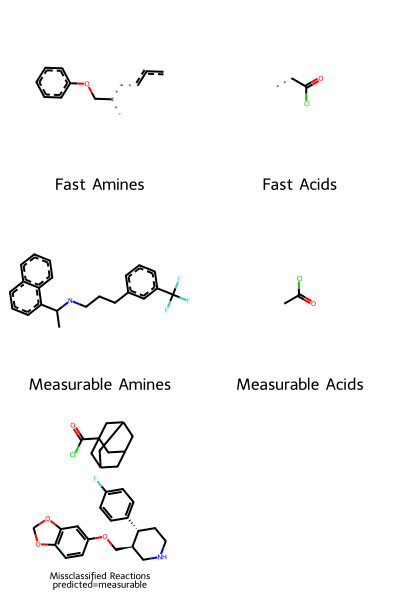

In [52]:
from rdkit import Chem
from rdkit.Chem import rdFMCS, Draw

# Convert SMILES to RDKit Mol objects
fast_mols_amines = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == True]['amine_smiles']]
fast_mols_acids = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == True]['acid_smiles']]

measurables_mols_amines = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == False]['amine_smiles']]
measurables_mols_acids = [Chem.MolFromSmiles(sm) for sm in preds[preds['Fast_unmeasurable'] == False]['acid_smiles']]

missclassified_mols_rxn = [Chem.MolFromSmiles(sm) for sm in misclassified['rxn_smiles']]
missclassified_preds = [ "measurable" if missclass == 0 else "fast" for missclass in misclassified['predicted_class']]

# Find the Maximum Common Substructure (MCS)
all_mols = [fast_mols_amines, fast_mols_acids, measurables_mols_amines, measurables_mols_acids]
mcs_mols = []
for i, mols in enumerate(all_mols):
    res = rdFMCS.FindMCS(mols)
    mcs_smarts = res.smartsString
    mcs_mol = Chem.MolFromSmarts(mcs_smarts)
    mcs_mols.append(mcs_mol)
    
    
Draw.MolsToGridImage(mcs_mols+missclassified_mols_rxn, molsPerRow=2, subImgSize=(200,200), 
                     legends=['Fast Amines', 
                              'Fast Acids', 
                              'Measurable Amines', 
                              'Measurable Acids', 
                              f'Missclassified Reactions\npredicted={missclassified_preds[len(missclassified_preds)-1]}'])